# 📊 Exploratory Data Analysis (EDA) - LIAR Dataset

This notebook contains the initial analysis of the raw data. Our goal is to understand the underlying data structure, check for missing values, and analyze the distribution of the target variable (truthfulness labels). This will directly inform our choice of evaluation metrics and help us avoid the "Accuracy Paradox" when dealing with imbalanced classes.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')

## 1. Defining Columns and Loading Data
Since the `.tsv` files from the LIAR dataset do not contain headers, we must explicitly define the names of the 14 columns according to the official dataset documentation.

In [2]:
# Define the original 14 columns of the LIAR dataset
columns = [
    "id", "label", "statement", "subjects", "speaker", 
    "speaker_job", "state_info", "party_affiliation", 
    "barely_true_counts", "false_counts", "half_true_counts", 
    "mostly_true_counts", "pants_on_fire_counts", "context"
]

# Paths are relative to the 'notebooks/' directory
train_path = "../liar_dataset/train.tsv"
test_path = "../liar_dataset/test.tsv"
valid_path = "../liar_dataset/valid.tsv"

# Load the data
train_df = pd.read_csv(train_path, sep="\t", names=columns)
test_df = pd.read_csv(test_path, sep="\t", names=columns)
valid_df = pd.read_csv(valid_path, sep="\t", names=columns)

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")
print(f"Validation set shape: {valid_df.shape}")

# View the first 3 rows
train_df.head(3)

Train set shape: (10240, 14)
Test set shape: (1267, 14)
Validation set shape: (1284, 14)


,id,label,statement,subjects,speaker,speaker_job,state_info,party_affiliation,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver


## 2. Class Distribution (Target Variable)
Here, we examine whether our target classes are balanced. If the classes are heavily imbalanced, using `Accuracy` as an evaluation metric will be completely misleading. In such cases, relying on `Macro F1-Score` and `Precision/Recall` provides a much more realistic evaluation of the model's performance.

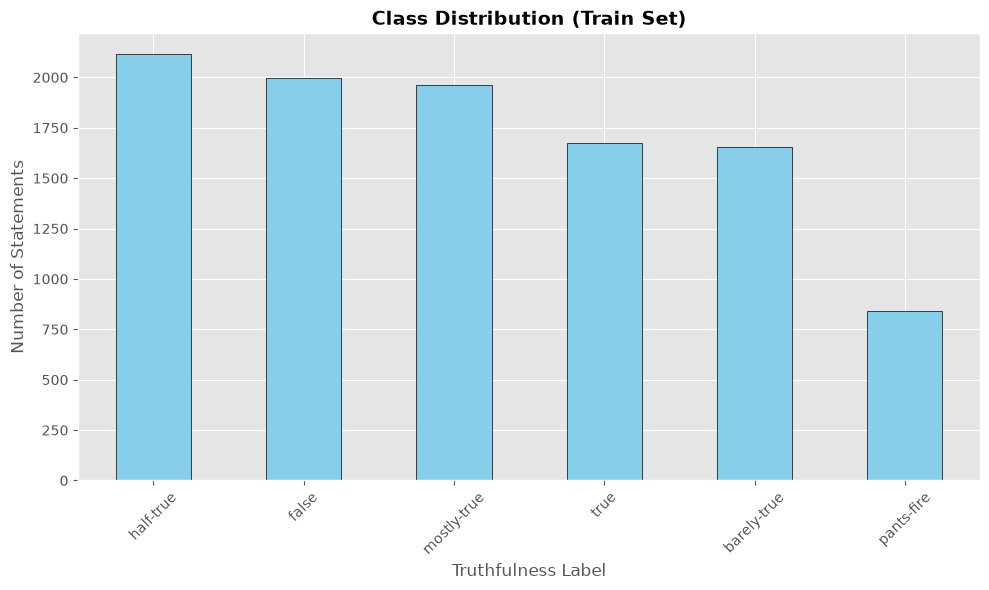

Percentage distribution of classes:
label
half-true      20.64
false          19.48
mostly-true    19.16
true           16.37
barely-true    16.15
pants-fire      8.19
Name: proportion, dtype: float64


In [3]:
# Count the occurrences of each class in the training set
label_counts = train_df['label'].value_counts()

# Plot the distribution
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Class Distribution (Train Set)', fontsize=14, fontweight='bold')
plt.xlabel('Truthfulness Label', fontsize=12)
plt.ylabel('Number of Statements', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the exact percentage breakdown
print("Percentage distribution of classes:")
print(round(train_df['label'].value_counts(normalize=True) * 100, 2))

## 3. Missing Data Analysis
Before moving forward with NLP vectorization and model training, we need to identify any columns containing missing data (NaN) to determine the appropriate imputation or removal strategy.

In [4]:
# Checking for missing data
missing_data = train_df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if not missing_data.empty:
    print("Columns with missing values:")
    print(missing_data)
else:
    print("There are no missing values in the data")

Columns with missing values:
speaker_job             2898
state_info              2210
context                  102
speaker                    2
subjects                   2
barely_true_counts         2
party_affiliation          2
false_counts               2
half_true_counts           2
mostly_true_counts         2
pants_on_fire_counts       2
dtype: int64
